In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Day14_Food_Delivery_Visualization_Dataset.csv")

display(df.head())
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


Dataset shape: (360, 16)
Columns: ['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine', 'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']


Data Overview

In [2]:
display(df.describe(include="all").T)
print("Missing values:")
display(df.isnull().sum().to_frame("Missing Values"))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_Batch_ID,360,360,FD0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,360,222,2025-04-26,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,360,12,June,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day,360,7,Saturday,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,360,8,Bengaluru,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cuisine,360,6,Healthy,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Channel,360,3,App,211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather,360,4,Clear,146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Orders,360.0,NaN,NaN,NaN,147.647222,33.387161,58.0,123.75,147.0,169.0,235.0
Average_Order_Value,360.0,NaN,NaN,NaN,409.151083,70.249186,243.76,353.84,412.41,464.945,575.94


Missing values:


,Missing Values
Order_Batch_ID,0
Date,0
Month,0
Day,0
City,0
Cuisine,0
Order_Channel,0
Weather,0
Orders,0
Average_Order_Value,0


Line Plot

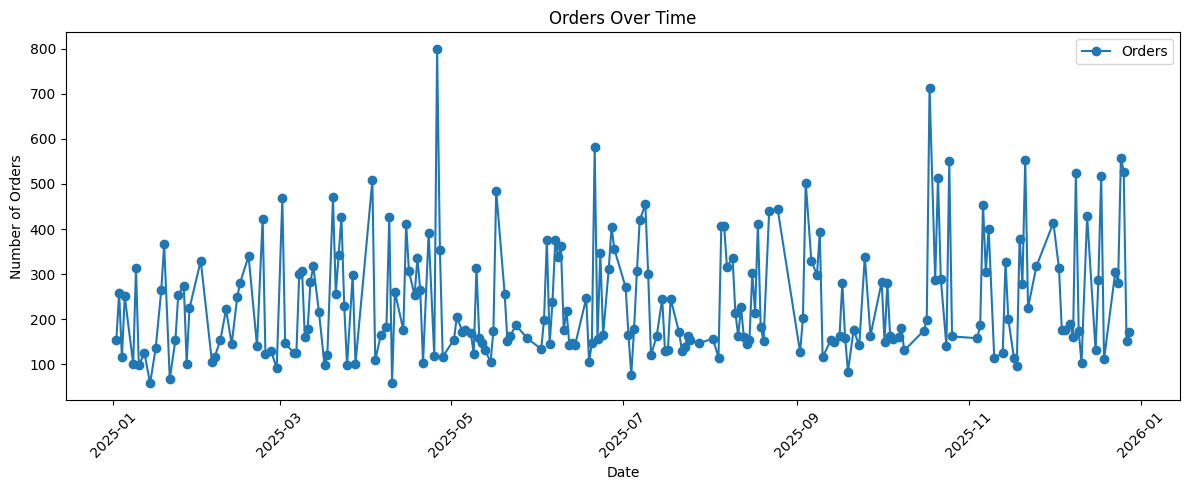

In [3]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
daily_orders = df.groupby("Date")["Orders"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_orders.index, daily_orders.values, marker="o", label="Orders")
plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation

Line Plot — Revenue Over Time

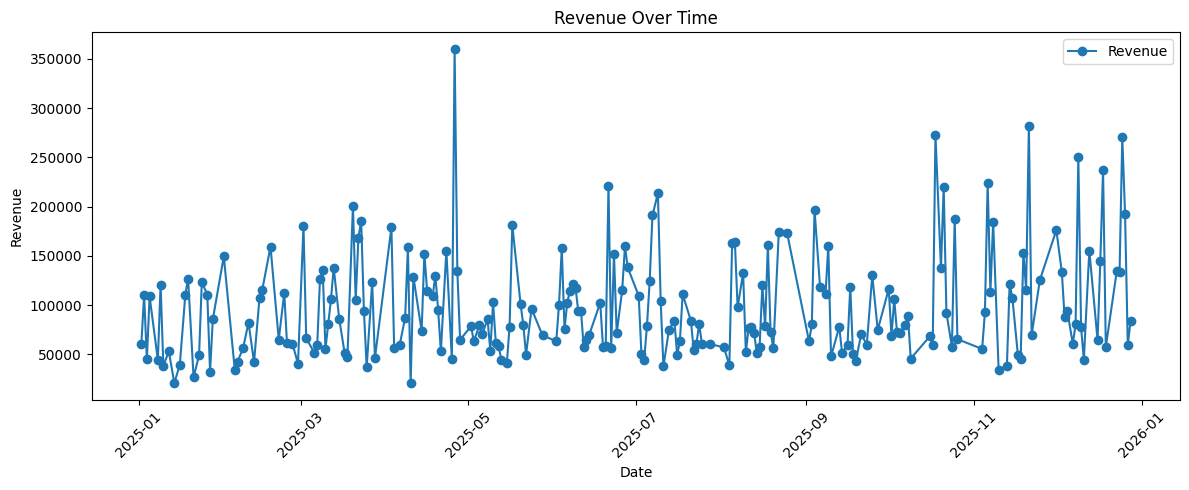

In [4]:
daily_revenue = df.groupby("Date")["Revenue"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_revenue.index, daily_revenue.values, marker="o", label="Revenue")
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation
This chart shows how revenue changes across the observed period. Comparing it with the orders trend helps identify whether revenue changes are mainly associated with order volume.

Bar Chart — Average Revenue by City

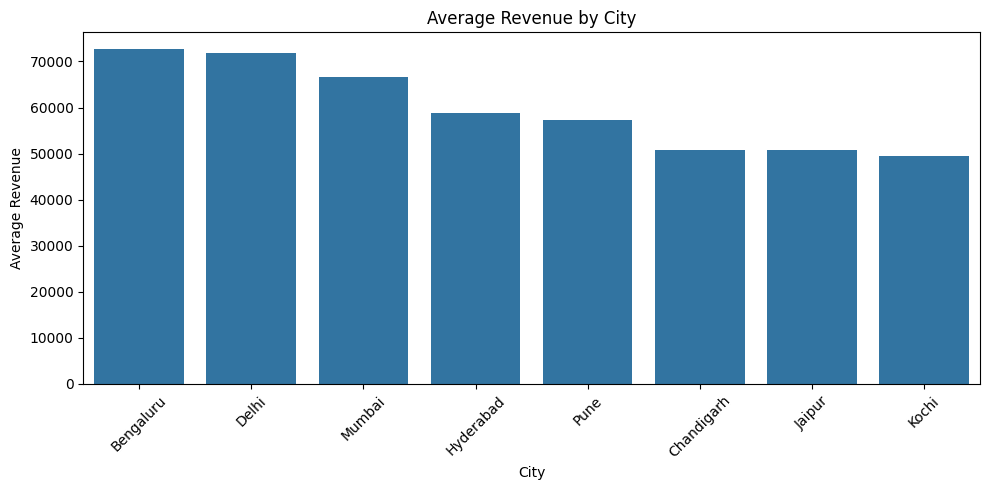

In [5]:
city_revenue = df.groupby("City")["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=city_revenue.index, y=city_revenue.values)
plt.title("Average Revenue by City")
plt.xlabel("City")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation
Bengaluru has the highest average revenue among the cities in the dataset, making it the strongest city-level performer by this measure.

Bar Chart — Average Revenue by Cuisine

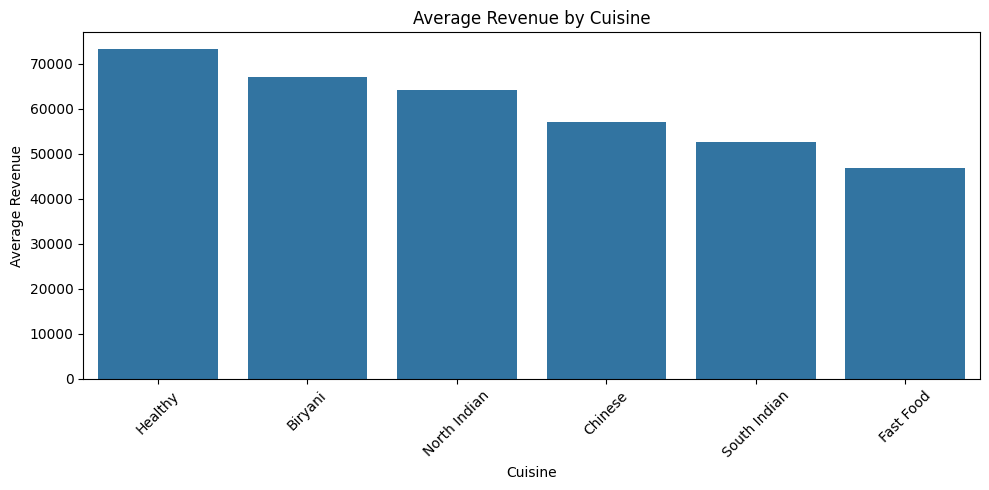

In [6]:
cuisine_revenue = df.groupby("Cuisine")["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=cuisine_revenue.index, y=cuisine_revenue.values)
plt.title("Average Revenue by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation
Healthy has the highest average revenue among the cuisine categories, indicating meaningful performance differences between cuisines.

Scatter Plot — Marketing Spend vs Revenue

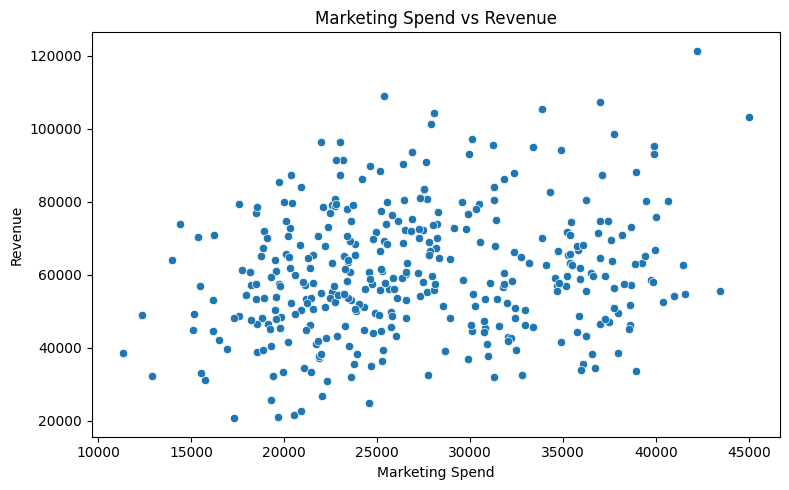

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Marketing_Spend", y="Revenue")
plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

Interpretation
Marketing spend and revenue have a Pearson correlation of approximately **0.20**. The plot shows the direction and strength of their association, but correlation does not establish causation.

Histogram — Delivery Time

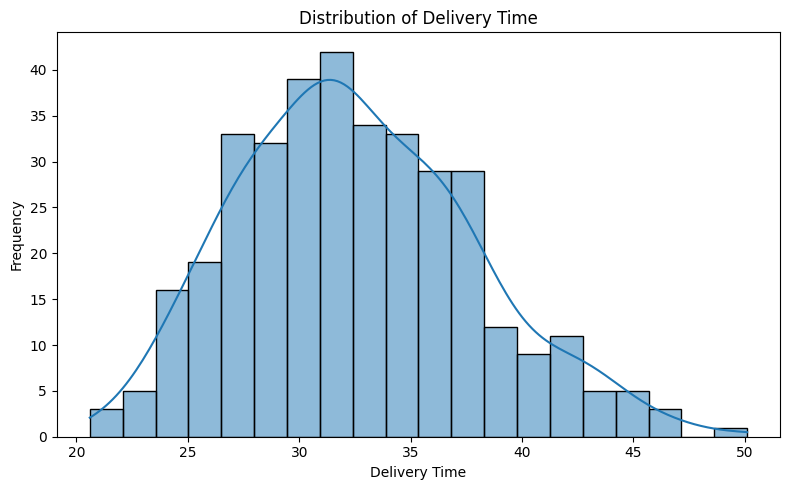

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Avg_Delivery_Minutes", bins=20, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Interpretation
The histogram shows the typical delivery-time range, concentration of observations, and possible unusually long or short delivery times.

 Histogram — Revenue

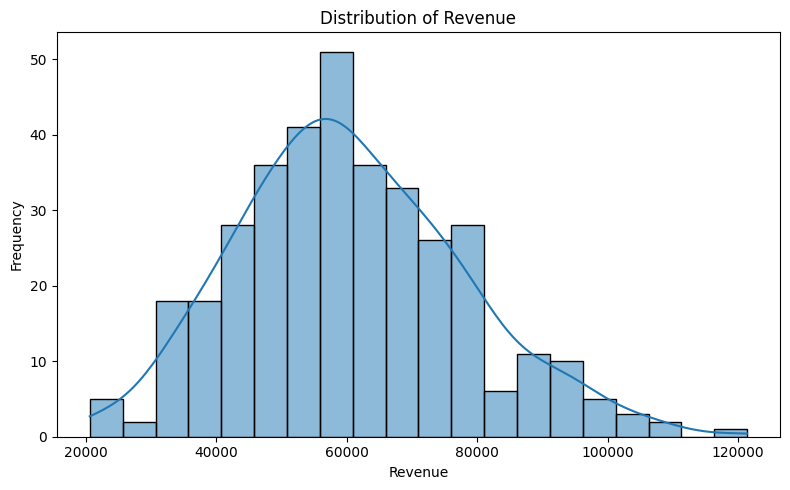

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Revenue", bins=20, kde=True)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Interpretation
The revenue distribution shows the typical revenue range and whether high-value observations create a long tail.

Box Plot — Revenue by City

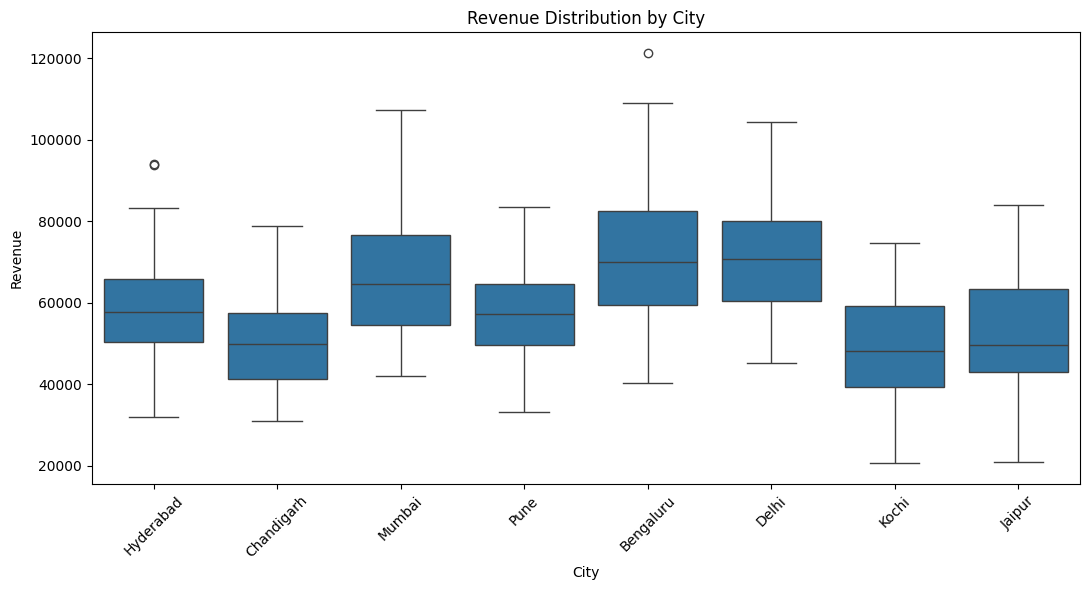

In [10]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x="City", y="Revenue")
plt.title("Revenue Distribution by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation
The box plot compares median revenue, spread, and potential outliers across cities. It shows whether city-level differences are consistent or driven by a few observations.

Violin Plot — Revenue by Cuisine

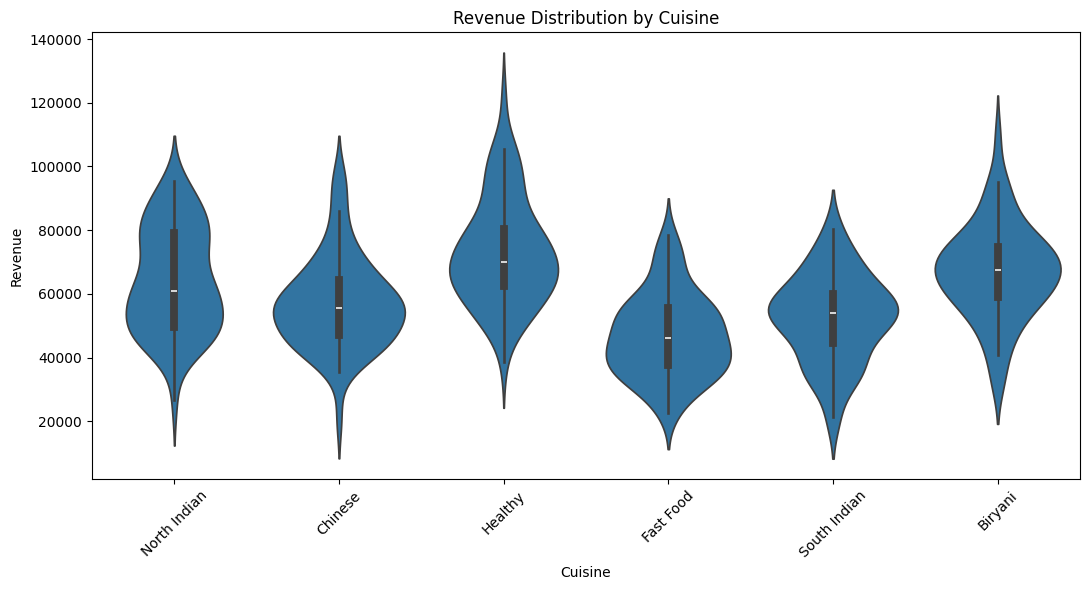

In [11]:
plt.figure(figsize=(11, 6))
sns.violinplot(data=df, x="Cuisine", y="Revenue")
plt.title("Revenue Distribution by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation
The violin plot shows the distribution and density of revenue for each cuisine, making differences in concentration and variability easier to compare.

Count Plot — Weather Conditions

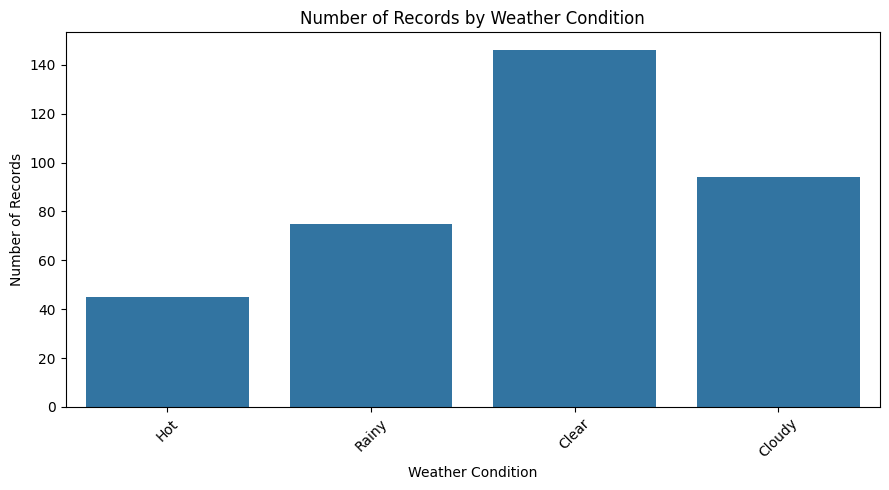

In [12]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Weather")
plt.title("Number of Records by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation
The count plot shows how frequently each weather condition occurs. Clear has the highest average revenue when revenue is grouped by weather condition.

Count Plot — Order Channels

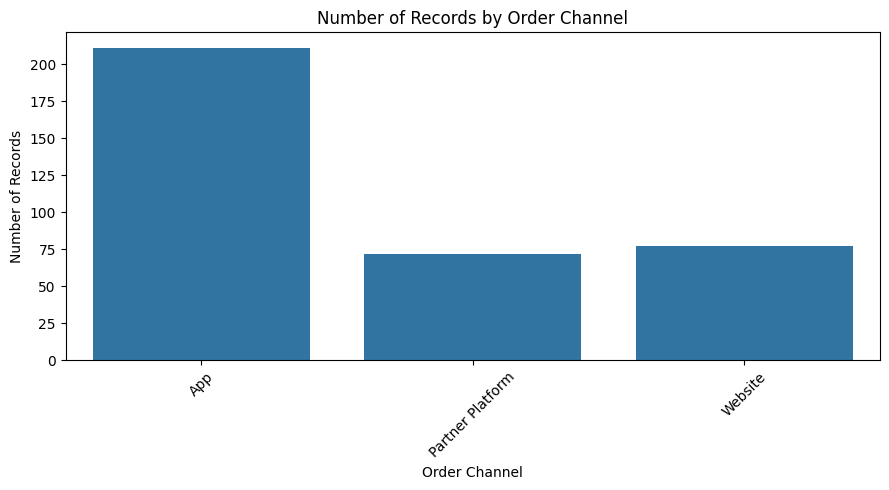

In [13]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Order_Channel")
plt.title("Number of Records by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation
The count plot compares the usage of different ordering channels. App has the highest average revenue among the available channels.

Scatter Plot — Delivery Time vs Customer Rating

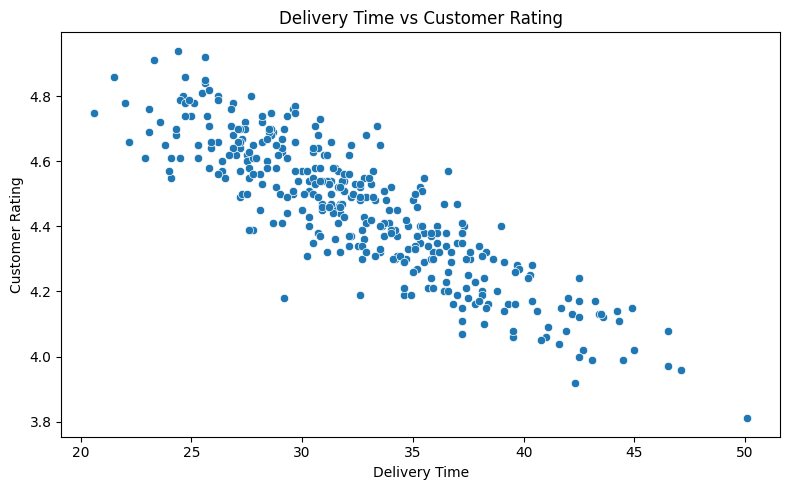

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Avg_Delivery_Minutes", y="Customer_Rating")
plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Time")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

Interpretation
Delivery time and customer rating have a Pearson correlation of approximately **-0.88**. The negative relationship indicates that longer delivery times tend to be associated with lower ratings.

 Correlation Heatmap

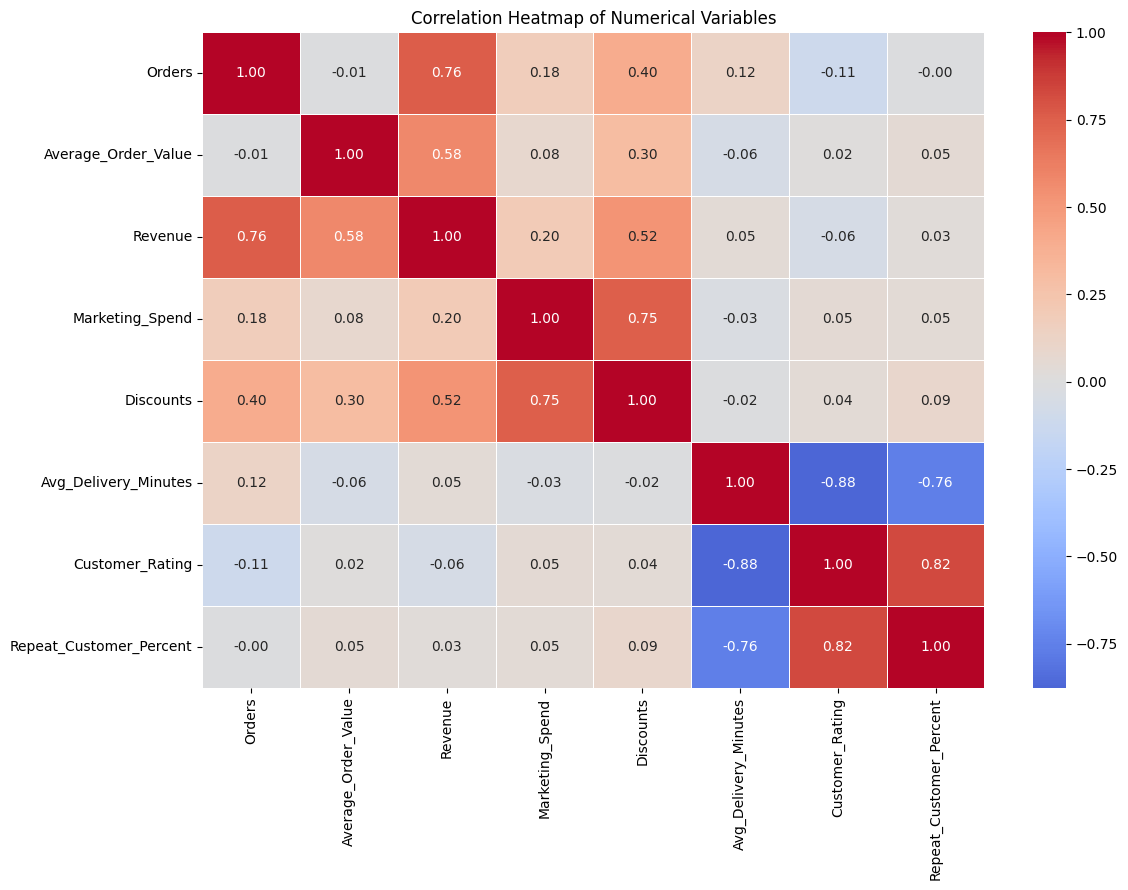

In [15]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

Interpretation
The heatmap provides an overall view of numerical relationships. Strong positive values indicate variables that tend to increase together, while negative values indicate inverse relationships. The strongest relationships can be used to identify areas for deeper business analysis.